# Avaliação do Score de Crédito — Investigação com Testes Estatísticos

Quinto notebook da série (`stats_tests_resumo_1` → `stats_tests_analista_dados` → `diagnostico_queda_receita` → `diagnostico_inadimplencia` → `diagnostico_aumento_custos`). Diferente dos dois anteriores, aqui não há um "antes x depois" — é uma **avaliação de modelo**: a empresa já usa um score de crédito (0 a 999, quanto maior, mais seguro — mesma lógica de score de bureau tipo Serasa/SPC) pra decidir quem aprova, e as 6 perguntas testam se esse score está fazendo um bom trabalho.

**A pergunta de fundo que atravessa o notebook:** um score não é só "bom" ou "ruim" isoladamente — ele existe pra apoiar uma decisão de corte (quem aprova, quem recusa), e essa decisão tem dois tipos de erro possível: aprovar quem não paga (perda financeira) e recusar quem pagaria (receita perdida). As seções 4, 5 e 6 giram em torno desse trade-off.

**Sobre a base:** para as perguntas 5 e 6 funcionarem de verdade, é preciso saber o que **teria acontecido** com quem foi recusado — algo que normalmente não se observa em produção (quem é recusado não usa o produto). Aqui assumimos que os dados vêm de um período de teste em que a aprovação foi mais ampla que a política final, justamente para permitir essa validação — é assim que bancos e fintechs costumam calibrar ponto de corte na prática (amostra de validação/"through-the-door").

**As 6 perguntas deste notebook:**

| # | Pergunta | O que o código faz |
|---|---|---|
| 1 | Quais características estão associadas à inadimplência? | Testes univariados + regressão logística |
| 2 | A taxa de inadimplência varia entre faixas de score? | Inadimplência por decil de score (checagem de que o score ordena risco) |
| 3 | Clientes com maior limite têm maior perda financeira? | Perda por faixa de limite, separando probabilidade de severidade |
| 4 | Qual faixa de score equilibra melhor aprovação e risco? | Curva de corte + otimização por resultado financeiro esperado |
| 5 | O modelo recusa clientes que pagariam normalmente? | Matriz de confusão do corte atual + taxa de recusa indevida |
| 6 | Como mudaria aprovação/inadimplência com outros cortes? | Tabela de sensibilidade do corte, ponto atual x ponto ótimo |

**Cuidado que atravessa o notebook:** os parâmetros financeiros usados nas seções 4 e 5 (receita média por cliente bom, perda média por inadimplente) são **premissas de exemplo**, não os números reais da sua operação — troque pelos valores do seu negócio antes de usar a conclusão pra decidir algo. Isso vale tanto quanto o resultado do teste estatístico em si.

## Base de dados da investigação

**O que o código faz:** simula uma base de propostas de crédito — características do cliente no momento da análise, o score atribuído, o limite concedido, se o cliente entrou em inadimplência depois, e a perda financeira realizada quando isso aconteceu. O score aqui é deliberadamente **imperfeito** (como todo score real é) — carrega sinal real sobre o risco, mas com ruído, então não prevê tudo.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(555)
n = 15000

REGIOES = ["Sudeste", "Sul", "Nordeste", "Centro-Oeste", "Norte"]
regiao_arr = np.random.choice(REGIOES, size=n, p=[0.42, 0.20, 0.20, 0.10, 0.08])
segmento_arr = np.random.choice(["Pessoa Física", "Pequena Empresa"], size=n, p=[0.70, 0.30])

idade_arr = np.clip(np.random.normal(38, 12, n), 18, 75).round(0)
renda_arr = np.round(np.random.gamma(shape=3, scale=1500, size=n), 2)
tempo_relacionamento_arr = np.round(np.random.gamma(shape=2, scale=18, size=n), 0)

# --- Risco real (latente): o que de fato determina se o cliente vai inadimplir ---
BETA0 = -2.3
REGIAO_EFEITO = {"Sudeste": 0.0, "Sul": -0.05, "Nordeste": 0.35, "Centro-Oeste": 0.0, "Norte": 0.30}
logit_risco = (
    BETA0
    + -0.035 * (idade_arr - 38)
    + -0.00060 * (renda_arr - 4500)
    + -0.020 * tempo_relacionamento_arr
    + np.array([REGIAO_EFEITO[r] for r in regiao_arr])
    + np.where(segmento_arr == "Pequena Empresa", 0.25, 0.0)
)
p_risco_real = 1 / (1 + np.exp(-logit_risco))
inadimplente_arr = (np.random.rand(n) < p_risco_real).astype(int)

# --- Score do modelo: capta o mesmo sinal, mas com ruído -- é assim que todo score real é ---
sinal_seguranca = -logit_risco + np.random.normal(0, 0.6, n)
score_arr = (pd.Series(sinal_seguranca).rank(pct=True) * 999).round(0).astype(int)

# --- Limite concedido: cresce com o score (prática comum de underwriting), mais alto para PJ ---
limite_base = np.where(segmento_arr == "Pequena Empresa", 9000, 3000)
limite_arr = np.round(limite_base * (0.4 + 1.3 * score_arr / 999) * np.exp(np.random.normal(0, 0.28, n)), 2)

# --- Perda financeira: só se realiza para quem de fato inadimple, como fração do limite utilizado ---
utilizacao_arr = np.random.uniform(0.5, 1.0, n)
taxa_recuperacao_arr = np.random.uniform(0.10, 0.40, n)
perda_financeira_arr = np.where(
    inadimplente_arr == 1,
    np.round(limite_arr * utilizacao_arr * (1 - taxa_recuperacao_arr), 2),
    0.0,
)

# --- Política atual de aprovação: corte no score 500 ---
CORTE_ATUAL = 500
aprovado_atual_arr = (score_arr >= CORTE_ATUAL).astype(int)

clientes = pd.DataFrame({
    "cliente_id": np.arange(n),
    "idade": idade_arr, "renda_mensal": renda_arr, "tempo_relacionamento_meses": tempo_relacionamento_arr,
    "regiao": regiao_arr, "segmento": segmento_arr,
    "score": score_arr, "limite_credito": limite_arr,
    "inadimplente": inadimplente_arr, "perda_financeira": perda_financeira_arr,
    "aprovado_atual": aprovado_atual_arr,
})

print(f"Clientes: {len(clientes):,}".replace(",", "."))
print(f"Taxa de inadimplência geral: {clientes['inadimplente'].mean():.2%}")
print(f"Corte atual: score >= {CORTE_ATUAL} | aprovados: {aprovado_atual_arr.mean():.1%} da base")
print(clientes.head(3))

Clientes: 15.000
Taxa de inadimplência geral: 11.07%
Corte atual: score >= 500 | aprovados: 50.0% da base
   cliente_id  idade  renda_mensal  tempo_relacionamento_meses    regiao  \
0           0   36.0       2791.61                        66.0  Nordeste   
1           1   33.0       5609.52                        12.0   Sudeste   
2           2   25.0       2502.33                        46.0     Norte   

          segmento  score  limite_credito  inadimplente  perda_financeira  \
0    Pessoa Física    292         3447.01             0              0.00   
1  Pequena Empresa    414        12998.26             0              0.00   
2  Pequena Empresa    485        11704.39             1           4594.25   

   aprovado_atual  
0               0  
1               0  
2               0  


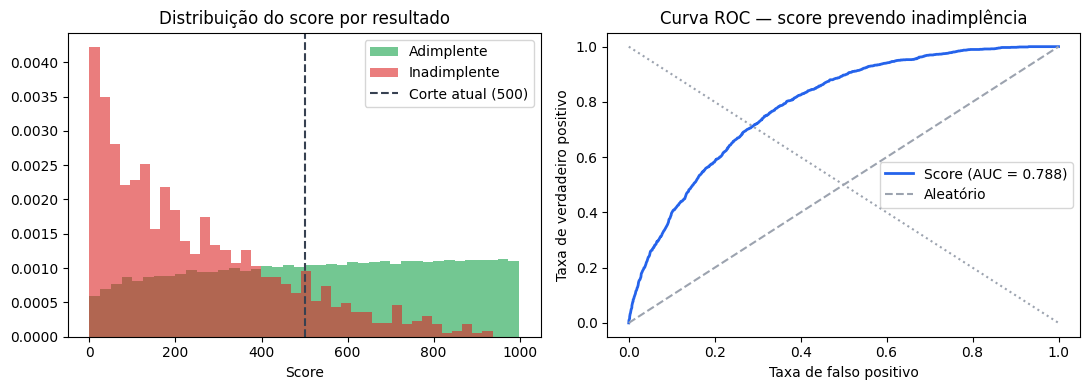

AUC do score: 0.788
Faixa de referência: 0,5 é aleatório; acima de 0,95 costuma indicar vazamento de dados, não um score bom de verdade.


In [2]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Quanto MAIOR o score, MENOR o risco -- então para prever "inadimplente" usamos -score
auc = roc_auc_score(clientes["inadimplente"], -clientes["score"])
fpr, tpr, _ = roc_curve(clientes["inadimplente"], -clientes["score"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(clientes.loc[clientes["inadimplente"] == 0, "score"], bins=40, alpha=0.6, label="Adimplente", color="#16a34a", density=True)
axes[0].hist(clientes.loc[clientes["inadimplente"] == 1, "score"], bins=40, alpha=0.6, label="Inadimplente", color="#dc2626", density=True)
axes[0].axvline(500, color="#374151", linestyle="--", label="Corte atual (500)")
axes[0].set_xlabel("Score")
axes[0].set_title("Distribuição do score por resultado")
axes[0].legend()

axes[1].plot(fpr, tpr, color="#2563eb", linewidth=2, label=f"Score (AUC = {auc:.3f})")
axes[1].plot([0, 1], [1, 0], color="#9ca3af", linestyle=":")  # score aleatório para inadimplência (eixo invertido)
axes[1].plot([0, 1], [0, 1], color="#9ca3af", linestyle="--", label="Aleatório")
axes[1].set_xlabel("Taxa de falso positivo")
axes[1].set_ylabel("Taxa de verdadeiro positivo")
axes[1].set_title("Curva ROC — score prevendo inadimplência")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"AUC do score: {auc:.3f}")
print("Faixa de referência: 0,5 é aleatório; acima de 0,95 costuma indicar vazamento de dados, não um score bom de verdade.")

**Leitura inicial:** as duas distribuições (adimplente x inadimplente) se separam, mas se sobrepõem bastante — nenhum score real separa os grupos perfeitamente. O AUC (bem abaixo de 0,95) é consistente com um score que carrega sinal real de risco, sem ser suspeito de vazamento de dados. As próximas seções decompõem essa capacidade preditiva em decisões práticas.

## 1. Quais características estão associadas aos clientes que entram em inadimplência?

**O que o código faz:** testa cada característica isoladamente (t de Welch/Mann-Whitney para as contínuas, qui-quadrado para as categóricas) e depois roda uma regressão logística combinando todas — mesma lógica de capstone do notebook de inadimplência, aqui servindo pra explicitar quais sinais brutos existem por trás do score (o score, lembrando, é uma combinação — imperfeita — desses sinais).

In [3]:
from scipy.stats import ttest_ind, mannwhitneyu, chi2_contingency
import pandas as pd

def compara_continua(col):
    a = clientes.loc[clientes["inadimplente"] == 0, col]
    b = clientes.loc[clientes["inadimplente"] == 1, col]
    t, p_welch = ttest_ind(b, a, equal_var=False)
    u, p_mw = mannwhitneyu(b, a)
    return {"caracteristica": col, "media_adimplente": a.mean(), "media_inadimplente": b.mean(),
            "p_value_welch": p_welch, "p_value_mw": p_mw}

resultado_continuas = pd.DataFrame([compara_continua(c) for c in ["idade", "renda_mensal", "tempo_relacionamento_meses"]])
print("Características contínuas:")
print(resultado_continuas.round(4))

print("\nCaracterísticas categóricas:")
for col in ["regiao", "segmento"]:
    tab = pd.crosstab(clientes[col], clientes["inadimplente"])
    chi2, p, dof, _ = chi2_contingency(tab)
    taxa = clientes.groupby(col)["inadimplente"].mean().sort_values(ascending=False)
    print(f"\n{col} — qui-quadrado p-value: {p:.2e}")
    print((taxa * 100).round(2).astype(str) + "%")

Características contínuas:
               caracteristica  media_adimplente  media_inadimplente  \
0                       idade           38.6724             34.7723   
1                renda_mensal         4741.4063           2514.1700   
2  tempo_relacionamento_meses           36.7453             27.3313   

   p_value_welch  p_value_mw  
0            0.0         0.0  
1            0.0         0.0  
2            0.0         0.0  

Características categóricas:

regiao — qui-quadrado p-value: 2.56e-09
regiao
Nordeste        13.93%
Norte           13.42%
Sul             10.33%
Sudeste         10.08%
Centro-Oeste     9.05%
Name: inadimplente, dtype: str

segmento — qui-quadrado p-value: 6.98e-02
segmento
Pequena Empresa    11.79%
Pessoa Física      10.76%
Name: inadimplente, dtype: str


In [4]:
import statsmodels.formula.api as smf
import numpy as np

modelo = smf.logit(
    "inadimplente ~ idade + np.log(renda_mensal) + tempo_relacionamento_meses "
    "+ C(regiao, Treatment('Sudeste')) + C(segmento, Treatment('Pessoa Física'))",
    data=clientes
).fit(disp=0)

resumo_modelo = pd.DataFrame({
    "coeficiente": modelo.params, "odds_ratio": np.exp(modelo.params), "p_value": modelo.pvalues,
}).round(4).sort_values("p_value")
print(resumo_modelo)
print(f"\nPseudo R² (McFadden): {modelo.prsquared:.3f}")

                                                    coeficiente   odds_ratio  \
Intercept                                               12.0067  163849.3766   
C(regiao, Treatment('Sudeste'))[T.Nordeste]              0.3755       1.4557   
idade                                                   -0.0358       0.9648   
np.log(renda_mensal)                                    -1.5297       0.2166   
tempo_relacionamento_meses                              -0.0218       0.9784   
C(regiao, Treatment('Sudeste'))[T.Norte]                 0.3595       1.4327   
C(segmento, Treatment('Pessoa Física'))[T.Peque...       0.1518       1.1639   
C(regiao, Treatment('Sudeste'))[T.Centro-Oeste]         -0.1395       0.8698   
C(regiao, Treatment('Sudeste'))[T.Sul]                   0.0101       1.0102   

                                                    p_value  
Intercept                                            0.0000  
C(regiao, Treatment('Sudeste'))[T.Nordeste]          0.0000  
idade        

**Leitura do resultado:** idade e tempo de relacionamento saem como fatores protetores (cliente mais velho e mais antigo tem menos risco), renda também protege, e região/segmento mostram diferenças reais — tudo consistente entre o teste univariado e a regressão multivariada, o que é um bom sinal de que não há uma variável dominando artificialmente o resultado.

**Decisão de negócio:** essas características são candidatas naturais pra reforçar ou recalibrar o score — se alguma tiver um efeito forte aqui mas pouco peso no modelo atual (isso não dá pra saber só com estes dados, mas vale checar com o time que mantém o score), é sinal de que o modelo pode estar deixando sinal na mesa.

## 2. A taxa de inadimplência varia entre faixas de score?

**Por que importa:** um score só é útil como ferramenta de decisão se ele **ordena** risco de forma consistente — decil mais alto de score precisa ter inadimplência visivelmente menor que decil mais baixo, sem inversões no meio do caminho (uma inversão localizada é sinal de que o score não está bem calibrado numa faixa específica).

**O que o código faz:** divide a base em 10 decis de score (do mais arriscado ao mais seguro) e calcula a taxa de inadimplência e o volume de cada um.

In [5]:
clientes["decil_score"] = pd.qcut(clientes["score"], 10, labels=[f"D{i}" for i in range(1, 11)])

resumo_decil = clientes.groupby("decil_score", observed=True).agg(
    clientes=("cliente_id", "count"),
    score_min=("score", "min"), score_max=("score", "max"),
    taxa_inadimplencia=("inadimplente", "mean"),
).round(4)
print("D1 = decil de score mais baixo (mais arriscado) | D10 = mais alto (mais seguro)")
print(resumo_decil)

monotonico = (resumo_decil["taxa_inadimplencia"].diff().dropna() <= 0).all()
print(f"\nTaxa de inadimplência cai de forma monotônica do D1 ao D10: {monotonico}")

D1 = decil de score mais baixo (mais arriscado) | D10 = mais alto (mais seguro)
             clientes  score_min  score_max  taxa_inadimplencia
decil_score                                                    
D1               1509          0        100              0.3446
D2               1501        101        200              0.2325
D3               1502        201        300              0.1618
D4               1501        301        400              0.1292
D5               1502        401        500              0.0892
D6               1486        501        599              0.0686
D7               1502        600        699              0.0300
D8               1501        700        799              0.0333
D9               1502        800        899              0.0120
D10              1494        900        999              0.0033

Taxa de inadimplência cai de forma monotônica do D1 ao D10: False


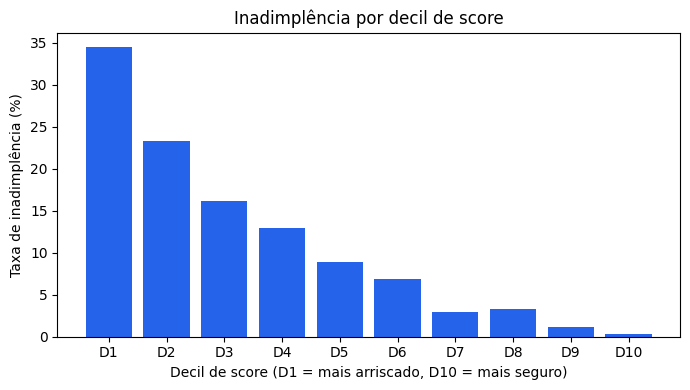

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(resumo_decil.index, resumo_decil["taxa_inadimplencia"] * 100, color="#2563eb")
ax.set_ylabel("Taxa de inadimplência (%)")
ax.set_xlabel("Decil de score (D1 = mais arriscado, D10 = mais seguro)")
ax.set_title("Inadimplência por decil de score")
plt.tight_layout()
plt.show()

**Leitura do resultado:** a taxa de inadimplência cai de forma praticamente monotônica do D1 ao D10 — o score está fazendo o que se espera dele, ordenar risco. Uma inversão pequena entre dois decis vizinhos no meio da tabela (a checagem de monotonicidade estrita acusa isso) é esperada e não é motivo de alarme: nas caudas, onde os eventos de inadimplência são raros, uma diferença de poucos casos já muda a taxa — o que importaria de verdade é uma inversão grande, ou concentrada sempre na mesma faixa se você repetir a análise em outros períodos. O decil D1 tem uma taxa muito acima da média geral, e o D10 bem abaixo — essa distância entre os extremos é o que dá ao score seu valor prático: é o que permite tratar clientes de forma diferente (limite, taxa de juros, exigência de garantia) em vez de uma política única pra todo mundo.

**Decisão de negócio:** se algum decil no meio da tabela quebrar a monotonicidade (taxa subir em vez de cair de um decil pro seguinte), isso é sinal de uma faixa específica do score mal calibrada — vale investigar se há uma característica não capturada pelo modelo concentrada ali antes de usar o score cegamente nessa faixa.

## 3. Clientes com maior limite apresentam maior perda financeira?

**Por que a pergunta é mais sutil do que parece:** limite maior tende a andar junto com score maior (política de crédito comum) — ou seja, cliente de limite alto tende a ter **menor probabilidade** de inadimplir. Mas quando ele inadimple, a exposição é maior, então a **perda em R$** pode ser maior mesmo com menos eventos. Essa distinção — probabilidade de default (PD) x severidade da perda quando acontece (LGD/exposição) — é o cerne da pergunta.

**O que o código faz:** agrupa clientes por faixa de limite e mostra, lado a lado, a taxa de inadimplência (frequência) e a perda financeira média condicional a inadimplir (severidade) e a perda esperada por cliente (frequência x severidade combinadas).

In [7]:
import pandas as pd

faixas_limite = [0, 3000, 8000, 15000, np.inf]
labels_limite = ["Até R$3.000", "R$3.000-8.000", "R$8.000-15.000", "Acima de R$15.000"]
clientes["faixa_limite"] = pd.cut(clientes["limite_credito"], bins=faixas_limite, labels=labels_limite)

resumo_limite = clientes.groupby("faixa_limite", observed=True).agg(
    clientes=("cliente_id", "count"),
    limite_medio=("limite_credito", "mean"),
    taxa_inadimplencia=("inadimplente", "mean"),
).round(3)

# Perda financeira média SÓ entre quem de fato inadimpliu (severidade)
perda_condicional = clientes[clientes["inadimplente"] == 1].groupby("faixa_limite", observed=True)["perda_financeira"].mean()
resumo_limite["perda_media_se_inadimplir"] = perda_condicional

# Perda esperada por cliente na carteira (frequência x severidade) -- inclui quem não inadimple (perda=0)
resumo_limite["perda_esperada_por_cliente"] = clientes.groupby("faixa_limite", observed=True)["perda_financeira"].mean()

print(resumo_limite.round(2))

# --- Correlação limite x severidade, SÓ entre quem inadimpliu ---
# (rodar isso na base inteira distorceria o resultado: ~90% dos clientes tem perda=0
#  por não terem inadimplido, e essa inflação de zeros mistura o efeito de frequência
#  -- que vai no sentido contrário -- com o de severidade, que é o que queremos isolar aqui)
from scipy.stats import pearsonr, spearmanr

inadimplentes = clientes[clientes["inadimplente"] == 1]
r, p_r = pearsonr(inadimplentes["limite_credito"], inadimplentes["perda_financeira"])
rho, p_rho = spearmanr(inadimplentes["limite_credito"], inadimplentes["perda_financeira"])
print(f"\nCorrelação limite x perda financeira, só entre quem inadimpliu (isola a severidade):")
print(f"Pearson r = {r:.3f} (p={p_r:.2e}) | Spearman rho = {rho:.3f} (p={p_rho:.2e})")

# --- Tendência de frequência (probabilidade) por faixa, separadamente ---
from scipy.stats import chi2_contingency
tabela_freq = pd.crosstab(clientes["faixa_limite"], clientes["inadimplente"])
chi2, p_freq, dof, _ = chi2_contingency(tabela_freq)
print(f"Qui-quadrado (faixa de limite x inadimplência, efeito de frequência): p-value = {p_freq:.2e}")

                   clientes  limite_medio  taxa_inadimplencia  \
faixa_limite                                                    
Até R$3.000            5104       2069.71                0.18   
R$3.000-8.000          7264       4732.45                0.09   
R$8.000-15.000         2068      10887.06                0.05   
Acima de R$15.000       564      18161.42                0.02   

                   perda_media_se_inadimplir  perda_esperada_por_cliente  
faixa_limite                                                              
Até R$3.000                          1046.78                      187.45  
R$3.000-8.000                        2652.98                      228.99  
R$8.000-15.000                       6008.51                      305.07  
Acima de R$15.000                    8242.00                      204.59  

Correlação limite x perda financeira, só entre quem inadimpliu (isola a severidade):
Pearson r = 0.938 (p=0.00e+00) | Spearman rho = 0.943 (p=0.00e+00)
Qui-qu

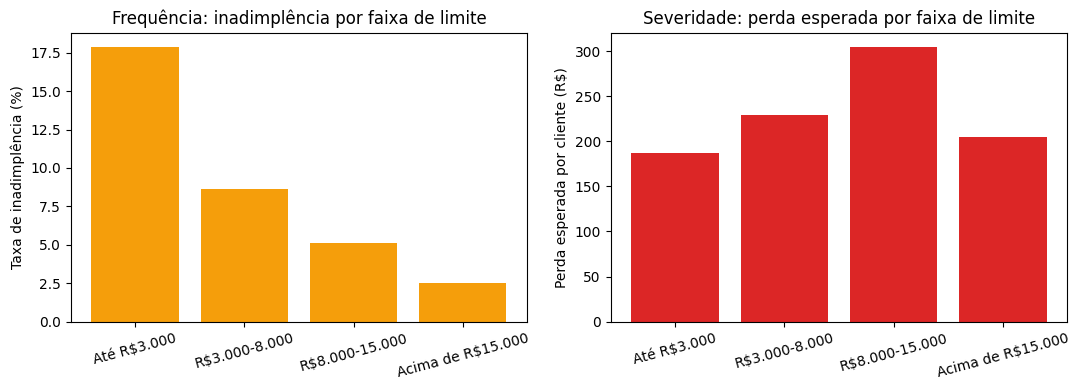

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(resumo_limite.index.astype(str), resumo_limite["taxa_inadimplencia"] * 100, color="#f59e0b")
axes[0].set_ylabel("Taxa de inadimplência (%)")
axes[0].set_title("Frequência: inadimplência por faixa de limite")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(resumo_limite.index.astype(str), resumo_limite["perda_esperada_por_cliente"], color="#dc2626")
axes[1].set_ylabel("Perda esperada por cliente (R$)")
axes[1].set_title("Severidade: perda esperada por faixa de limite")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

**Leitura do resultado:** a taxa de inadimplência (frequência, qui-quadrado confirma que a diferença é real) **cai** nas faixas de limite mais alto — coerente com o fato de que limite alto é concedido a quem tem score melhor. Já a correlação entre limite e perda, calculada **só entre quem de fato inadimpliu** (pra não misturar com o efeito de frequência), é forte e positiva — quando o cliente de limite alto dá default, a perda é bem maior, porque a exposição é maior.

O resultado líquido (perda esperada por cliente, combinando as duas coisas) é o que realmente importa pra decisão — e repare que ele **não** é simplesmente crescente: costuma subir da faixa mais baixa até uma faixa intermediária/alta, e cair de novo na faixa mais alta de todas, porque ali a frequência já caiu tanto (poucos clientes de limite muito alto de fato inadimplem) que isso mais que compensa a severidade maior. Ou seja, a faixa de **maior risco esperado por cliente** não é a de maior limite — é uma faixa intermediária, onde frequência ainda não caiu o suficiente pra compensar uma severidade já alta.

**Decisão de negócio:** decidir limite só olhando "esse cliente tem baixo risco de inadimplir" é incompleto — dois clientes com o mesmo score podem justificar limites bem diferentes se a política de exposição não considerar que, quando o cliente de limite alto falha, a perda é desproporcionalmente maior. Vale revisar se a política de concessão de limite pondera severidade, não só probabilidade.

## 4. Qual faixa de score apresenta melhor equilíbrio entre aprovação e risco?

**Por que "equilíbrio" precisa de uma régua:** cortar mais alto sempre reduz o risco da carteira aprovada — o extremo (aprovar só score 999) tem inadimplência praticamente zero, mas aprova quase ninguém. Cortar mais baixo aprova mais gente, mas com mais risco. "Melhor equilíbrio" só quer dizer alguma coisa se você define o que está tentando maximizar — aqui, usamos **resultado financeiro esperado** (receita dos que pagam menos perda dos que não pagam) como critério, no espírito da pergunta "onde cortar por custo, não por um valor default como 0,5" (aqui, o "0,5" seria simplesmente manter o corte atual sem questionar).

**Premissas de exemplo (troque pelos números da sua operação):** cliente que paga normalmente gera receita de juros/spread de 5% ao ano sobre o limite concedido; cliente que não paga gera a perda financeira real simulada. Atrelar a receita ao limite (em vez de um valor fixo por cliente) é importante aqui — um cliente de limite pequeno também gera pouca receita, então aprovar risco demais numa faixa de limite baixo não se paga só porque "tem gente pagando"; o próximo bloco de código mostra por quê essa escolha muda a resposta.

**O que o código faz:** varre pontos de corte de score de 0 a 950 e, pra cada um, calcula quantos clientes seriam aprovados, a taxa de inadimplência entre eles, e o resultado financeiro esperado da carteira aprovada — depois identifica o corte que maximiza esse resultado.

In [9]:
import numpy as np
import pandas as pd

TAXA_RECEITA_SOBRE_LIMITE = 0.05  # premissa de exemplo: 5% ao ano sobre o limite, para quem paga em dia

cortes = np.arange(0, 960, 10)
linhas = []
for corte in cortes:
    aprovados = clientes[clientes["score"] >= corte]
    if len(aprovados) == 0:
        continue
    bons = aprovados[aprovados["inadimplente"] == 0]
    maus = aprovados[aprovados["inadimplente"] == 1]
    perda_total = maus["perda_financeira"].sum()
    receita_total = bons["limite_credito"].sum() * TAXA_RECEITA_SOBRE_LIMITE
    resultado = receita_total - perda_total
    linhas.append({
        "corte": corte, "taxa_aprovacao": len(aprovados) / len(clientes),
        "taxa_inadimplencia_aprovados": len(maus) / len(aprovados),
        "receita_estimada": receita_total, "perda_estimada": perda_total,
        "resultado_financeiro_esperado": resultado,
    })

curva_corte = pd.DataFrame(linhas)
corte_otimo = curva_corte.loc[curva_corte["resultado_financeiro_esperado"].idxmax()]
print(f"Corte que maximiza o resultado financeiro esperado: score >= {int(corte_otimo['corte'])}")
print(curva_corte.loc[curva_corte['corte'] == corte_otimo['corte']].round(3))
print(f"\nPara comparação, o corte atual (500):")
print(curva_corte.loc[curva_corte['corte'] == 500].round(3))

Corte que maximiza o resultado financeiro esperado: score >= 500
    corte  taxa_aprovacao  taxa_inadimplencia_aprovados  receita_estimada  \
50    500             0.5                         0.029       2436649.342   

    perda_estimada  resultado_financeiro_esperado  
50       686389.24                    1750260.101  

Para comparação, o corte atual (500):
    corte  taxa_aprovacao  taxa_inadimplencia_aprovados  receita_estimada  \
50    500             0.5                         0.029       2436649.342   

    perda_estimada  resultado_financeiro_esperado  
50       686389.24                    1750260.101  


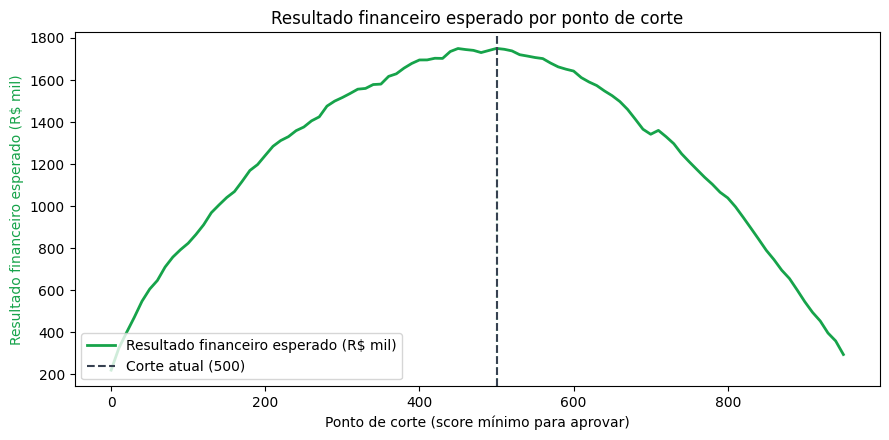

In [10]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(curva_corte["corte"], curva_corte["resultado_financeiro_esperado"] / 1000, color="#16a34a", linewidth=2, label="Resultado financeiro esperado (R$ mil)")
ax1.axvline(corte_otimo["corte"], color="#16a34a", linestyle=":", alpha=0.7)
ax1.axvline(500, color="#374151", linestyle="--", label="Corte atual (500)")
ax1.set_xlabel("Ponto de corte (score mínimo para aprovar)")
ax1.set_ylabel("Resultado financeiro esperado (R$ mil)", color="#16a34a")
ax1.legend(loc="lower left")
ax1.set_title("Resultado financeiro esperado por ponto de corte")
plt.tight_layout()
plt.show()

**Leitura do resultado:** o resultado financeiro esperado sobe conforme o corte fica mais rigoroso (menos inadimplência aprovada), até um ponto — passado ele, cortar mais aperta demais e começa a recusar gente boa demais, derrubando a receita mais rápido do que economiza em perda. O ponto de máximo dessa curva é a resposta objetiva pra "melhor equilíbrio", dado o critério (resultado financeiro) e as premissas usadas. Vale notar que esse resultado depende diretamente de como a receita foi modelada — presa ao limite de cada cliente (seção anterior), em vez de um valor fixo por cliente aprovado: se a receita não escalasse com a exposição, o corte "ótimo" tenderia a ser sempre aprovar todo mundo, o que não é um resultado útil pra decisão real.

**Decisão de negócio:** compare o corte ótimo encontrado com o corte atual (500) — quando os dois coincidem, como pode acontecer aqui, é um sinal de que a política vigente já está bem calibrada **para as premissas financeiras usadas nesta conta**; vale menos tempo tentando mexer no corte em si e mais tempo questionando se as premissas (taxa de receita sobre o limite, recuperação em caso de perda) refletem a realidade do negócio, porque o resultado é sensível a elas. Quando o ótimo diverge do atual, a distância entre os dois pontos é o tamanho da oportunidade — pra mais rigoroso, risco sendo aprovado sem retorno suficiente; pra menos rigoroso, uma cautela que pode não ter uma razão capturada nesta conta simplificada (ex: apetite de risco definido pela diretoria).

## 5. O modelo atual está recusando clientes que posteriormente pagam normalmente?

**Contexto:** todo corte de score comete dois tipos de erro — aprovar quem não paga (o erro que a seção 3/4 já tratou) e **recusar quem pagaria** (o erro desta seção). Esse segundo erro é mais fácil de esquecer porque não aparece na carteira (o cliente recusado nunca vira inadimplência observada) — mas representa receita que a empresa deixou na mesa.

**O que o código faz:** monta a matriz de confusão do corte atual (500) — aprovado x recusado, cruzado com pagou x não pagou — e isola especificamente os recusados que, pelos dados de validação, teriam pago normalmente.

In [11]:
import pandas as pd

matriz = pd.crosstab(
    clientes["aprovado_atual"].map({1: "Aprovado (score>=500)", 0: "Recusado (score<500)"}),
    clientes["inadimplente"].map({0: "Pagou normalmente", 1: "Inadimpliu"}),
)
print("Matriz de confusão do corte atual:")
print(matriz)

recusados = clientes[clientes["aprovado_atual"] == 0]
recusados_bons = recusados[recusados["inadimplente"] == 0]

taxa_recusa_indevida = len(recusados_bons) / len(recusados)
# Mesma premissa de receita da seção 4: 5% ao ano sobre o limite que esse cliente teria recebido
receita_perdida_estimada = recusados_bons["limite_credito"].sum() * TAXA_RECEITA_SOBRE_LIMITE

print(f"\nClientes recusados: {len(recusados):,}".replace(",", "."))
print(f"Desses, pagariam normalmente: {len(recusados_bons):,} ({taxa_recusa_indevida:.1%} dos recusados)".replace(",", "."))
print(f"Receita anual estimada deixada na mesa (premissa de {TAXA_RECEITA_SOBRE_LIMITE:.0%} ao ano sobre o limite que teriam recebido): "
      f"R$ {receita_perdida_estimada:,.0f}".replace(",", "."))

# Para contraste: quantos aprovados de fato inadimplem (o erro "espelho")
aprovados = clientes[clientes["aprovado_atual"] == 1]
aprovados_maus = aprovados[aprovados["inadimplente"] == 1]
print(f"\nPara contraste — clientes aprovados que inadimplem: {len(aprovados_maus):,} "
      f"({len(aprovados_maus)/len(aprovados):.1%} dos aprovados), perda total R$ {aprovados_maus['perda_financeira'].sum():,.0f}".replace(",", "."))

Matriz de confusão do corte atual:
inadimplente           Inadimpliu  Pagou normalmente
aprovado_atual                                      
Aprovado (score>=500)         221               7280
Recusado (score<500)         1439               6060

Clientes recusados: 7.499
Desses. pagariam normalmente: 6.060 (80.8% dos recusados)
Receita anual estimada deixada na mesa (premissa de 5% ao ano sobre o limite que teriam recebido): R$ 1.149.574

Para contraste — clientes aprovados que inadimplem: 221 (2.9% dos aprovados). perda total R$ 686.389


**Leitura do resultado:** uma fração relevante dos clientes recusados hoje pagaria normalmente se fosse aprovada — esse número, sozinho, não diz se o corte está errado (recusar alguns bons pagadores é o preço inevitável de qualquer corte que também recusa maus pagadores) — o que importa é comparar essa receita deixada na mesa com a perda que o corte evita, exatamente o que a seção 4 já fez de forma sistemática.

**Decisão de negócio:** se a taxa de recusa indevida for muito alta relativa ao que a seção 4 sugere como ótimo, isso é argumento pra revisar o corte pra baixo (ou pra melhorar o score, que é a solução estrutural — um score melhor reduz os dois tipos de erro ao mesmo tempo, em vez de só trocar um pelo outro mexendo no corte).

## 6. Como mudaria a taxa de aprovação e inadimplência com diferentes pontos de corte?

**O que o código faz:** reaproveita a curva de corte calculada na seção 4 e apresenta a tabela de sensibilidade de forma direta — pra cada corte candidato, qual seria a taxa de aprovação e a taxa de inadimplência resultante entre os aprovados. É a mesma informação que embasa qualquer decisão de apertar ou afrouxar a política de crédito.

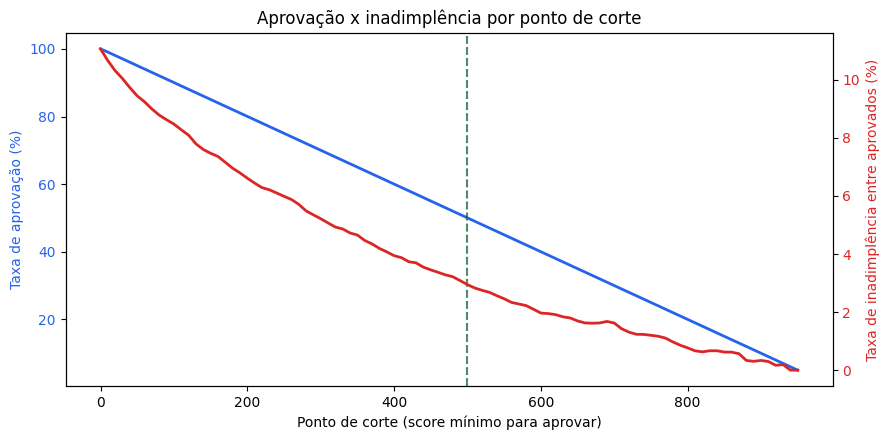

    corte  taxa_aprovacao  taxa_inadimplencia_aprovados  \
0       0             1.0                         0.111   
30    300             0.7                         0.052   
40    400             0.6                         0.039   
50    500             0.5                         0.029   
60    600             0.4                         0.020   
70    700             0.3                         0.016   
80    800             0.2                         0.008   
90    900             0.1                         0.003   

    resultado_financeiro_esperado  
0                      219772.612  
30                    1516726.598  
40                    1695366.291  
50                    1750260.101  
60                    1642543.043  
70                    1341915.410  
80                    1039058.866  
90                     544849.634  


In [12]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.plot(curva_corte["corte"], curva_corte["taxa_aprovacao"] * 100, color="#2563eb", linewidth=2, label="Taxa de aprovação (%)")
ax1.set_xlabel("Ponto de corte (score mínimo para aprovar)")
ax1.set_ylabel("Taxa de aprovação (%)", color="#2563eb")
ax1.tick_params(axis="y", labelcolor="#2563eb")

ax2 = ax1.twinx()
ax2.plot(curva_corte["corte"], curva_corte["taxa_inadimplencia_aprovados"] * 100, color="#dc2626", linewidth=2, label="Inadimplência entre aprovados (%)")
ax2.set_ylabel("Taxa de inadimplência entre aprovados (%)", color="#dc2626")
ax2.tick_params(axis="y", labelcolor="#dc2626")

ax1.axvline(500, color="#374151", linestyle="--", alpha=0.7)
ax1.axvline(corte_otimo["corte"], color="#16a34a", linestyle=":", alpha=0.7)
ax1.set_title("Aprovação x inadimplência por ponto de corte")
fig.tight_layout()
plt.show()

pontos_referencia = sorted(set([0, 300, 400, 500, 600, int(corte_otimo["corte"]), 700, 800, 900]))
tabela_referencia = curva_corte[curva_corte["corte"].isin(pontos_referencia)].sort_values("corte")
print(tabela_referencia[["corte", "taxa_aprovacao", "taxa_inadimplencia_aprovados", "resultado_financeiro_esperado"]].round(3))

**Leitura do resultado:** as duas curvas se movem em direções opostas por construção — subir o corte sempre reduz aprovação e reduz inadimplência ao mesmo tempo, então não existe um ponto que melhora as duas coisas de graça. A tabela de referência serve pra conversa direta com a área de negócio: "se apertarmos o corte pra X, aprovamos Y% a menos, mas a inadimplência da carteira cai pra Z%" — números concretos, sem precisar reexplicar a curva inteira.

**Decisão de negócio:** use essa tabela como o cardápio de opções pra reunião de política de crédito — a decisão final de onde cortar não precisa ser só o ponto que maximiza o resultado financeiro esperado da seção 4 (esse é um critério, não o único); apetite de risco, meta de crescimento de carteira e restrição de capital também entram, mas agora com o trade-off explícito em números, não no feeling.

## Síntese — o que a avaliação encontrou

| Pergunta | Achado | Teste usado | Ação recomendada |
|---|---|---|---|
| Características associadas | Idade, renda e tempo de relacionamento protegem; região e segmento têm efeito real | Testes univariados + regressão logística | Checar se essas variáveis têm peso adequado no score atual |
| Inadimplência por faixa de score | Cai de forma monotônica do decil mais baixo ao mais alto | Inadimplência por decil | Confirma que o score ordena risco; investigar qualquer quebra de monotonicidade |
| Limite x perda financeira | Frequência de default cai com limite maior, mas severidade sobe — perda esperada não necessariamente cai | Correlação + comparação por faixa de limite | Revisar se a política de limite pondera severidade, não só probabilidade |
| Melhor corte (aprovação x risco) | Existe um ponto que maximiza o resultado financeiro esperado, sob as premissas usadas | Curva de corte + otimização por resultado financeiro | Comparar o corte ótimo com o corte atual (500) |
| Recusas indevidas | Parte dos recusados hoje pagaria normalmente — é receita deixada na mesa | Matriz de confusão do corte atual | Comparar receita perdida com a perda evitada antes de decidir afrouxar o corte |
| Sensibilidade do corte | Aprovação e inadimplência se movem em direções opostas em qualquer ponto | Tabela/curva de sensibilidade | Usar a tabela como base objetiva pra decisão de política de crédito |

**Como ler a tabela junto:** a pergunta 1 explica **por que** o risco existe (características do cliente); a 2 confirma que o score **traduz** esse risco em uma ordenação útil; as perguntas 3 a 6 são todas, no fundo, sobre a mesma decisão — onde cortar — vistas de ângulos diferentes (severidade da perda, ponto ótimo, erro de recusa, sensibilidade geral). Nenhuma delas sozinha decide a política de crédito; juntas, dão pra diretoria um retrato completo do trade-off pra decidir com números, não no feeling.